# Detection & Analysis of Pre-SN Outburst Simulations

[View our paper here](https://iopscience.iop.org/article/10.3847/1538-4357/ad973d) for details on our cleaning and binning method, as well as our pre-SN outburst detection process!

## Settings 
### Load the config file and preset column names

In [1]:
# ==== User Settings ====

# Enter the config file name:
CONFIG_FILE = "config.ini"

# Enter the column name preset to use 
# (see config file for more; options: "atlas", "rubin", "tess"):
PRESET = "atlas"

# =======================

import sys
import numpy as np
import pandas as pd
from typing import Optional

from download import load_config, make_dir_if_not_exists
from lightcurve import PresetColumnNames, Supernova, AveragedSupernova, LightCurve, SimDetecLightCurve, SimDetecSupernova
from plot import Plot, PlotLimits
from utils import reformat_dir, get_config_flags
from generate_detec_table import ContaminationTable, Model, SimDetecTable, SimDetecTables, EfficiencyTable, AtlasSimDetecLoop

# load config
config = load_config(CONFIG_FILE)

# load preset
print(f"\nLoading {PRESET} preset column names from {CONFIG_FILE}...")
colnames = PresetColumnNames(config, PRESET)
print(colnames.__str__())


Loading config file at config.ini...

Loading atlas preset column names from config.ini...
--- Required Columns ---
mjd: MJD
flux: uJy
dflux: duJy
--- Optional Columns ---
chisquare: chi/N
filt: F
mag: m
dmag: dm
ra: RA
dec: Dec
--- Extra Columns to Copy ---
x, y, maj, min, phi, apfit, mag5sig, Sky, Obs


### Load the light curves

In [2]:
# ==== User Settings ====

# Enter the target SN name:
TNSNAME = '2019vxm'

# Enter the path to the data directory that contains the ATClean-readable SN directories:
INPUT_DIR = config["dir"]["atclean_input"]

# Enter the path to the directory that contains cleaned and binned light curves, plots, and more:
OUTPUT_DIR = config["dir"]["output"]

# Automatically save the generated plots in this notebook?:
SAVE_PLOTS = False
# Enter the path to a directory to optionally save plots:
PLOTS_DIR = f'{OUTPUT_DIR}/{TNSNAME}/bump_analysis/plots'

# Enter the filter for this light curve:
FILT = 'o'

# Enter the SN's discovery date:
DISCOVERY_DATE = 58650.0

# Enter the size of the MJD bins (in days):
MJD_BIN_SIZE = 1.0

# Enter the number of control light curves to load:
NUM_CONTROLS = 7 #int(config["download"]["num_controls"])

# =======================

# make sure tnsname not attached to end of input and output dirs
INPUT_DIR = reformat_dir(INPUT_DIR, TNSNAME)
OUTPUT_DIR = reformat_dir(OUTPUT_DIR, TNSNAME)

print(f'SN {TNSNAME}, filter {FILT}', end='')
if not DISCOVERY_DATE is None:
    print(f', discovery date: {DISCOVERY_DATE}')
print(f'Output directory (load cleaned and binned light curves): {OUTPUT_DIR}/{TNSNAME}')
print(f'Plots directory (save plots): {PLOTS_DIR}')

# load cleaned light curves
sn = Supernova(colnames, tnsname=TNSNAME, mjd0=DISCOVERY_DATE, filt=FILT)
sn.load_all(OUTPUT_DIR, NUM_CONTROLS, cleaned=True)

# load binned light curves
avg_sn = SimDetecSupernova(colnames, tnsname=TNSNAME, mjdbinsize=MJD_BIN_SIZE, mjd0=DISCOVERY_DATE, filt=FILT)
avg_sn.load_all(OUTPUT_DIR, NUM_CONTROLS)

p = Plot(PLOTS_DIR)

config_flags = get_config_flags(config)

SN 2019vxm, filter o, discovery date: 58650.0
Output directory (load cleaned and binned light curves): /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2019vxm
Plots directory (save plots): /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2019vxm/bump_analysis/plots

Loading SN light curve and 7 control light curves...
could not read /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2019vxm/controls/2019vxm_i001.o.clean.lc.txt!
Could not load control light curve 1; skipping...
Successfully loaded SN light curve and 7 control light curves (control indices: [2, 3, 4, 5, 6, 7, 8])
Updating column names for all light curves in this Supernova object (key: dflux_new, name: duJy_new)...

Loading averaged SN light curve and 7 averaged control light curves...
could not read /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2019vxm/controls/2019vxm_i001.o.1.00days.lc.txt!
Could not load averaged control light curve 1; skipping...
Successfully loa

## Plot cleaned original and binned pre-SN light curves

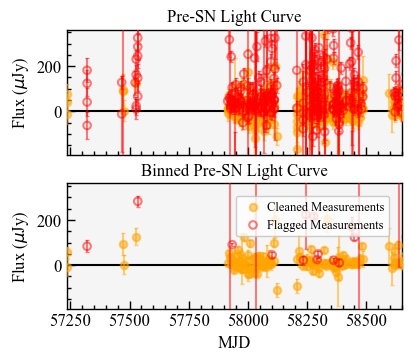

In [3]:
# ==== User Settings ====

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = None
YLIM_UPPER = None

# =======================

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

fig = p.plot_preSN(
    sn, 
    avg_sn, 
    config_flags,
    custom_lims=custom_lims,
    save=SAVE_PLOTS
)

## Plot all control light curves

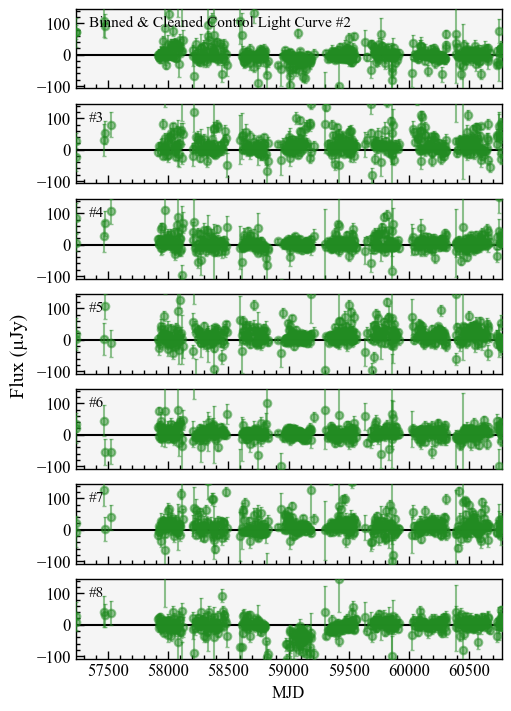

In [4]:
# ==== User Settings ====

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = None
YLIM_UPPER = None

# =======================

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

fig = p.plot_all_controls(
    avg_sn, 
    config_flags,
    custom_lims=custom_lims,
    two_columns=False,
    save=SAVE_PLOTS
)

## Plot binned pre-SN and control light curve

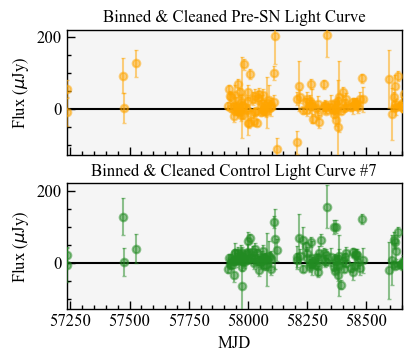

In [5]:
# ==== User Settings ====

# Enter the index of the control light curve to plot:
SELECT_CONTROL_INDEX = 7

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = None
YLIM_UPPER = None

# =======================

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

fig = p.plot_binned_examples(
    avg_sn, 
    SELECT_CONTROL_INDEX, 
    config_flags,
    custom_lims=custom_lims, 
    save=SAVE_PLOTS
)

## Get detection limits w.r.t. contamination

We use the bisection method to calculate the best detection limits $\Sigma_{\text{FOM, limit}}$ for each $\sigma_{\text{kernel}}$ with respect to a target contamination value.

We measure contamination for a given $\sigma_{\text{kernel}}$ and its corresponding $\Sigma_{\text{FOM, limit}}$ by counting the number of false positives in the control light curves (where a single false positive is defined by a continuous sequence of $\Sigma_{\text{FOM}}$ above $\Sigma_{\text{FOM, limit}}$). We record two alternative measures of contamination for evaluating a certain $\Sigma_{\text{FOM, limit}}$:

1. the number of positive control light curves (default option)
2. the total number of false positives throughout all control light curve

#### Plot observation seasons

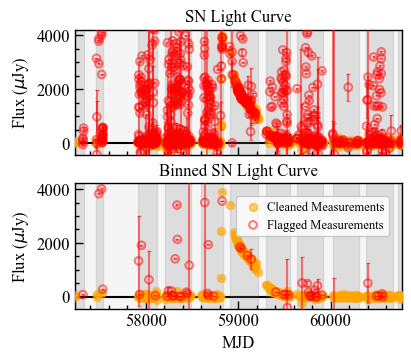

In [6]:
# ==== User Settings ====

# List the observation seasons
MJD_RANGES = [
    [57233, 57329], 
    [57466, 57536], 
    [57914, 58123],
    [58206, 58487],
    [58594, 58837],
    [58910, 59213],
    [59304, 59565],
    [59637, 59916],
    [60023, 60310],
    [60387, 60672],
    [60727, 60771]
]

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = None
YLIM_UPPER = None

# =======================

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)


fig = p.plot_mjd_ranges(
    sn, 
    avg_sn, 
    config_flags,
    MJD_RANGES,
    custom_lims=custom_lims,
    save=SAVE_PLOTS
)

### Exclude bad MJD ranges and determine valid observation seasons

In [7]:
# ==== User Settings ====

# Optionally expand observation gap MJD ranges by +-exclude_obs_edges days on either side 
# (set to None or 0 to skip):
EXCLUDE_OBS_EDGES = 30

# Optionally exclude additional bad observation seasons or MJD ranges 
# (set to None or empty list [] to skip):
EXCLUDE_MJD_RANGES = []

# =======================

In [8]:
import matplotlib
from matplotlib import gridspec
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
# plotting styles
plt.rc("axes", titlesize=17)
plt.rc("xtick", labelsize=12)
plt.rc("ytick", labelsize=12)
plt.rc("legend", fontsize=10)
plt.rcParams["font.size"] = 12
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.prop_cycle"] = matplotlib.cycler(
    color=["green", "blue", "purple", "magenta"]
)
matplotlib.rcParams["xtick.major.size"] = 6
matplotlib.rcParams["xtick.major.width"] = 1
matplotlib.rcParams["xtick.minor.size"] = 3
matplotlib.rcParams["xtick.minor.width"] = 1
matplotlib.rcParams["ytick.major.size"] = 6
matplotlib.rcParams["ytick.major.width"] = 1
matplotlib.rcParams["ytick.minor.size"] = 3
matplotlib.rcParams["ytick.minor.width"] = 1
matplotlib.rcParams["axes.linewidth"] = 1
MARKER_SIZE = 30
MARKER_EDGEWIDTH = 1.5

# color scheme
SN_FLUX_COLORS = {
    # ATLAS
    "o": "orange",  # Orange filter
    "c": "cyan",  # Cyan filter
    # Rubin
    "u": "purple",  # Ultraviolet (u-band)
    "g": "green",  # Green (g-band)
    "r": "salmon",  # Red (r-band)
    "i": "indigo",  # Near-infrared (i-band)
    "z": "brown",  # Deep red (z-band)
    "y": "darkred",  # Near-infrared (y-band)
    # TESS
    "tess": "pink",  # TESS uses a single wide bandpass (red-sensitive)
}
SN_FLAGGED_FLUX_COLOR = "red"
CONTROL_FLUX_COLOR = "steelblue"
SELECT_CONTROL_FLUX_COLOR = "forestgreen"
FACE_COLOR = "whitesmoke"
SN_FOM_COLOR = "deeppink"
CONTROL_FOM_COLOR = "cornflowerblue"
SELECT_CONTROL_FOM_COLOR = "mediumblue"
colors = [
    "indianred",
    "salmon",
    "sandybrown",
    "gold",
    "yellowgreen",
    "mediumseagreen",
    "turquoise",
    "lightskyblue",
    "plum",
    "palevioletred",
]
plt.rcParams["axes.prop_cycle"] = matplotlib.cycler(color=colors)

# line styles
SIM_BUMP_LS = "dashed"
FOM_LIMIT_LS = "dotted"

def get_lims(
    sn: Supernova = None,
    control_index: int = 0,
    flag: Optional[int] = None,
    custom_lims: Optional[PlotLimits] = None,
    indices = None,
    pre_sn: bool = False,
) -> PlotLimits:
    lims = PlotLimits()

    lims.set_xlims(
        sn.lcs[control_index].get_xlims(mjd0=sn.mjd0 if pre_sn else None)
    )
    if custom_lims is not None and custom_lims.get_xlims() is not None:
        lims.set_xlims(custom_lims.get_xlims())

    lims.set_ylims(
        sn.lcs[control_index].get_ylims(
            indices=indices, flag=flag, mjd0=sn.mjd0 if pre_sn else None
        )
    )
    if custom_lims is not None and custom_lims.get_ylims() is not None:
        lims.set_ylims(custom_lims.get_ylims())

    return lims

def _setup_ax(
    ax: Axes,
    lims: PlotLimits,
    xlabel: bool = True,
    ylabel: bool = True,
    xticks: bool = True,
    yticks: bool = True,
):
    ax.minorticks_on()
    ax.tick_params(direction="in", which="both")
    ax.set_facecolor(FACE_COLOR)
    ax.axhline(color="k", linewidth=1.5, zorder=0)

    if lims.get_xlims():
        ax.set_xlim(lims.get_xlims())
    if lims.get_ylims():
        ax.set_ylim(lims.get_ylims())

    if xlabel:
        ax.set_xlabel("MJD")
    if not xticks:
        ax.set_xticklabels([])

    if ylabel:
        ax.set_ylabel(r"Flux ($\mu$Jy)")
    if not yticks:
        ax.set_yticklabels([])

def _plot_lc(
    ax: Axes,
    obj: Supernova | LightCurve,
    control_index: int,
    color: str,
    indices = None,
    label: Optional[str] = None,
    open: bool = False,
):
    if isinstance(obj, Supernova):
        obj = obj.lcs[control_index]

    if indices is None:
        indices = obj.getindices()
    if not obj.can_plot(indices):
        print(
            f"WARNING: Light curve (control index #{control_index}) cannot be plotted with indices of length {len(indices)}; skipping..."
        )
        return

    ax.errorbar(
        obj.t.loc[indices, obj.colnames.mjd],
        obj.t.loc[indices, obj.colnames.flux],
        yerr=obj.t.loc[indices, obj.colnames.dflux_new],
        fmt="none",
        ecolor=color,
        elinewidth=1.5,
        capsize=1.2,
        c=color,
        alpha=0.5,
        zorder=10,
    )
    ax.scatter(
        obj.t.loc[indices, obj.colnames.mjd],
        obj.t.loc[indices, obj.colnames.flux],
        s=MARKER_SIZE,
        lw=MARKER_EDGEWIDTH,
        color=color,
        marker="o",
        alpha=0.5,
        zorder=10,
        label=label,
        facecolors="none" if open else None,
        edgecolors=color if open else None,
    )